In [1]:
import pathlib

import pandas as pd

In [2]:
data_folder = pathlib.Path("../../data/outputs/biolog")
all_scores_file = data_folder / "all_scores_data.csv"
untrained_file = data_folder / "untrained_data.csv"

In [3]:
all_scores = pd.read_csv(all_scores_file, index_col=0)
untrained = pd.read_csv(untrained_file, index_col=0)

In [4]:
all_scores

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef,feature
Carbon-N-Acetyl-Neuraminic-Acid-ch_biolog,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,0.649351,0.647019,0.619718,0.628571,0.611111,0.294637,cluster30
Carbon-Sucrose-ch_biolog,Carbon-Sucrose,ch_biolog,0.718750,0.702429,0.769231,0.750000,0.789474,0.410720,cluster30
Carbon-Dextrin-ch_biolog,Carbon-Dextrin,ch_biolog,0.644444,0.652778,0.609756,0.543478,0.694444,0.299456,cluster30
Carbon-Gelatin-ch_biolog,Carbon-Gelatin,ch_biolog,0.705882,0.702778,0.731183,0.708333,0.755556,0.408287,cluster30
Carbon-Salicin-ch_biolog,Carbon-Salicin,ch_biolog,0.702381,0.702496,0.698795,0.690476,0.707317,0.404877,cluster30
...,...,...,...,...,...,...,...,...,...
Carbon-D-Mannose-ch_biolog,Carbon-D-Mannose,ch_biolog,0.812500,0.782535,0.869565,0.895522,0.845070,0.540089,uniref90
Carbon-D-Mannitol-ch_biolog,Carbon-D-Mannitol,ch_biolog,0.838710,0.816810,0.881890,0.888889,0.875000,0.627896,uniref90
Carbon-L-Alanine-ch_biolog,Carbon-L-Alanine,ch_biolog,0.691489,0.710714,0.764228,0.886792,0.671429,0.370552,uniref90
Carbon-D-Cellobiose-ch_biolog,Carbon-D-Cellobiose,ch_biolog,0.673913,0.667641,0.716981,0.730769,0.703704,0.333018,uniref90


In [5]:
set(all_scores.feature)

{'cluster30',
 'cluster70',
 'eggnog_kegg',
 'kofam',
 'kofam_modules',
 'rast',
 'uniprot_trembl',
 'uniref30',
 'uniref90'}

In [34]:
len(set(all_scores.name))

64

In [6]:
all_scores_mean = all_scores.drop("name", axis=1).groupby(by=["category", "feature"]).mean().reset_index()
all_scores_mean

,category,feature,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef
0,ch_biolog,cluster30,0.748770,0.738368,0.755187,0.758290,0.764256,0.468301
1,ch_biolog,cluster70,0.739279,0.733458,0.744971,0.757848,0.747982,0.457861
2,ch_biolog,eggnog_kegg,0.758617,0.749378,0.766590,0.766306,0.776771,0.489417
3,ch_biolog,kofam,0.755837,0.745927,0.761905,0.764900,0.768634,0.481122
4,ch_biolog,kofam_modules,0.718701,0.715963,0.731441,0.739708,0.738372,0.418067
5,ch_biolog,rast,0.760837,0.750631,0.766618,0.768090,0.774724,0.490122
6,ch_biolog,uniprot_trembl,0.702190,0.709768,0.706065,0.755144,0.685575,0.406301
7,ch_biolog,uniref30,0.743869,0.735639,0.750507,0.759990,0.755808,0.465742
8,ch_biolog,uniref90,0.745091,0.735364,0.747753,0.769182,0.738697,0.459183


In [7]:
all_scores_mean_melt = all_scores_mean.melt(id_vars=["category", "feature"], var_name="score", value_name="value")
all_scores_mean_melt

,category,feature,score,value
0,ch_biolog,cluster30,accuracy,0.748770
1,ch_biolog,cluster70,accuracy,0.739279
2,ch_biolog,eggnog_kegg,accuracy,0.758617
3,ch_biolog,kofam,accuracy,0.755837
4,ch_biolog,kofam_modules,accuracy,0.718701
5,ch_biolog,rast,accuracy,0.760837
6,ch_biolog,uniprot_trembl,accuracy,0.702190
7,ch_biolog,uniref30,accuracy,0.743869
8,ch_biolog,uniref90,accuracy,0.745091
9,ch_biolog,cluster30,balanced_accuracy,0.738368


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
all_scores_melt = all_scores.melt(id_vars=["name", "category", "feature"], var_name='score', value_name='value')
all_scores_melt

,name,category,feature,score,value
0,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,cluster30,accuracy,0.649351
1,Carbon-Sucrose,ch_biolog,cluster30,accuracy,0.718750
2,Carbon-Dextrin,ch_biolog,cluster30,accuracy,0.644444
3,Carbon-Gelatin,ch_biolog,cluster30,accuracy,0.705882
4,Carbon-Salicin,ch_biolog,cluster30,accuracy,0.702381
...,...,...,...,...,...
3451,Carbon-D-Mannose,ch_biolog,uniref90,matthews_corrcoef,0.540089
3452,Carbon-D-Mannitol,ch_biolog,uniref90,matthews_corrcoef,0.627896
3453,Carbon-L-Alanine,ch_biolog,uniref90,matthews_corrcoef,0.370552
3454,Carbon-D-Cellobiose,ch_biolog,uniref90,matthews_corrcoef,0.333018


/Users/g8k/mambaforge/envs/trait-prediction/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/g8k/mambaforge/envs/trait-prediction/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


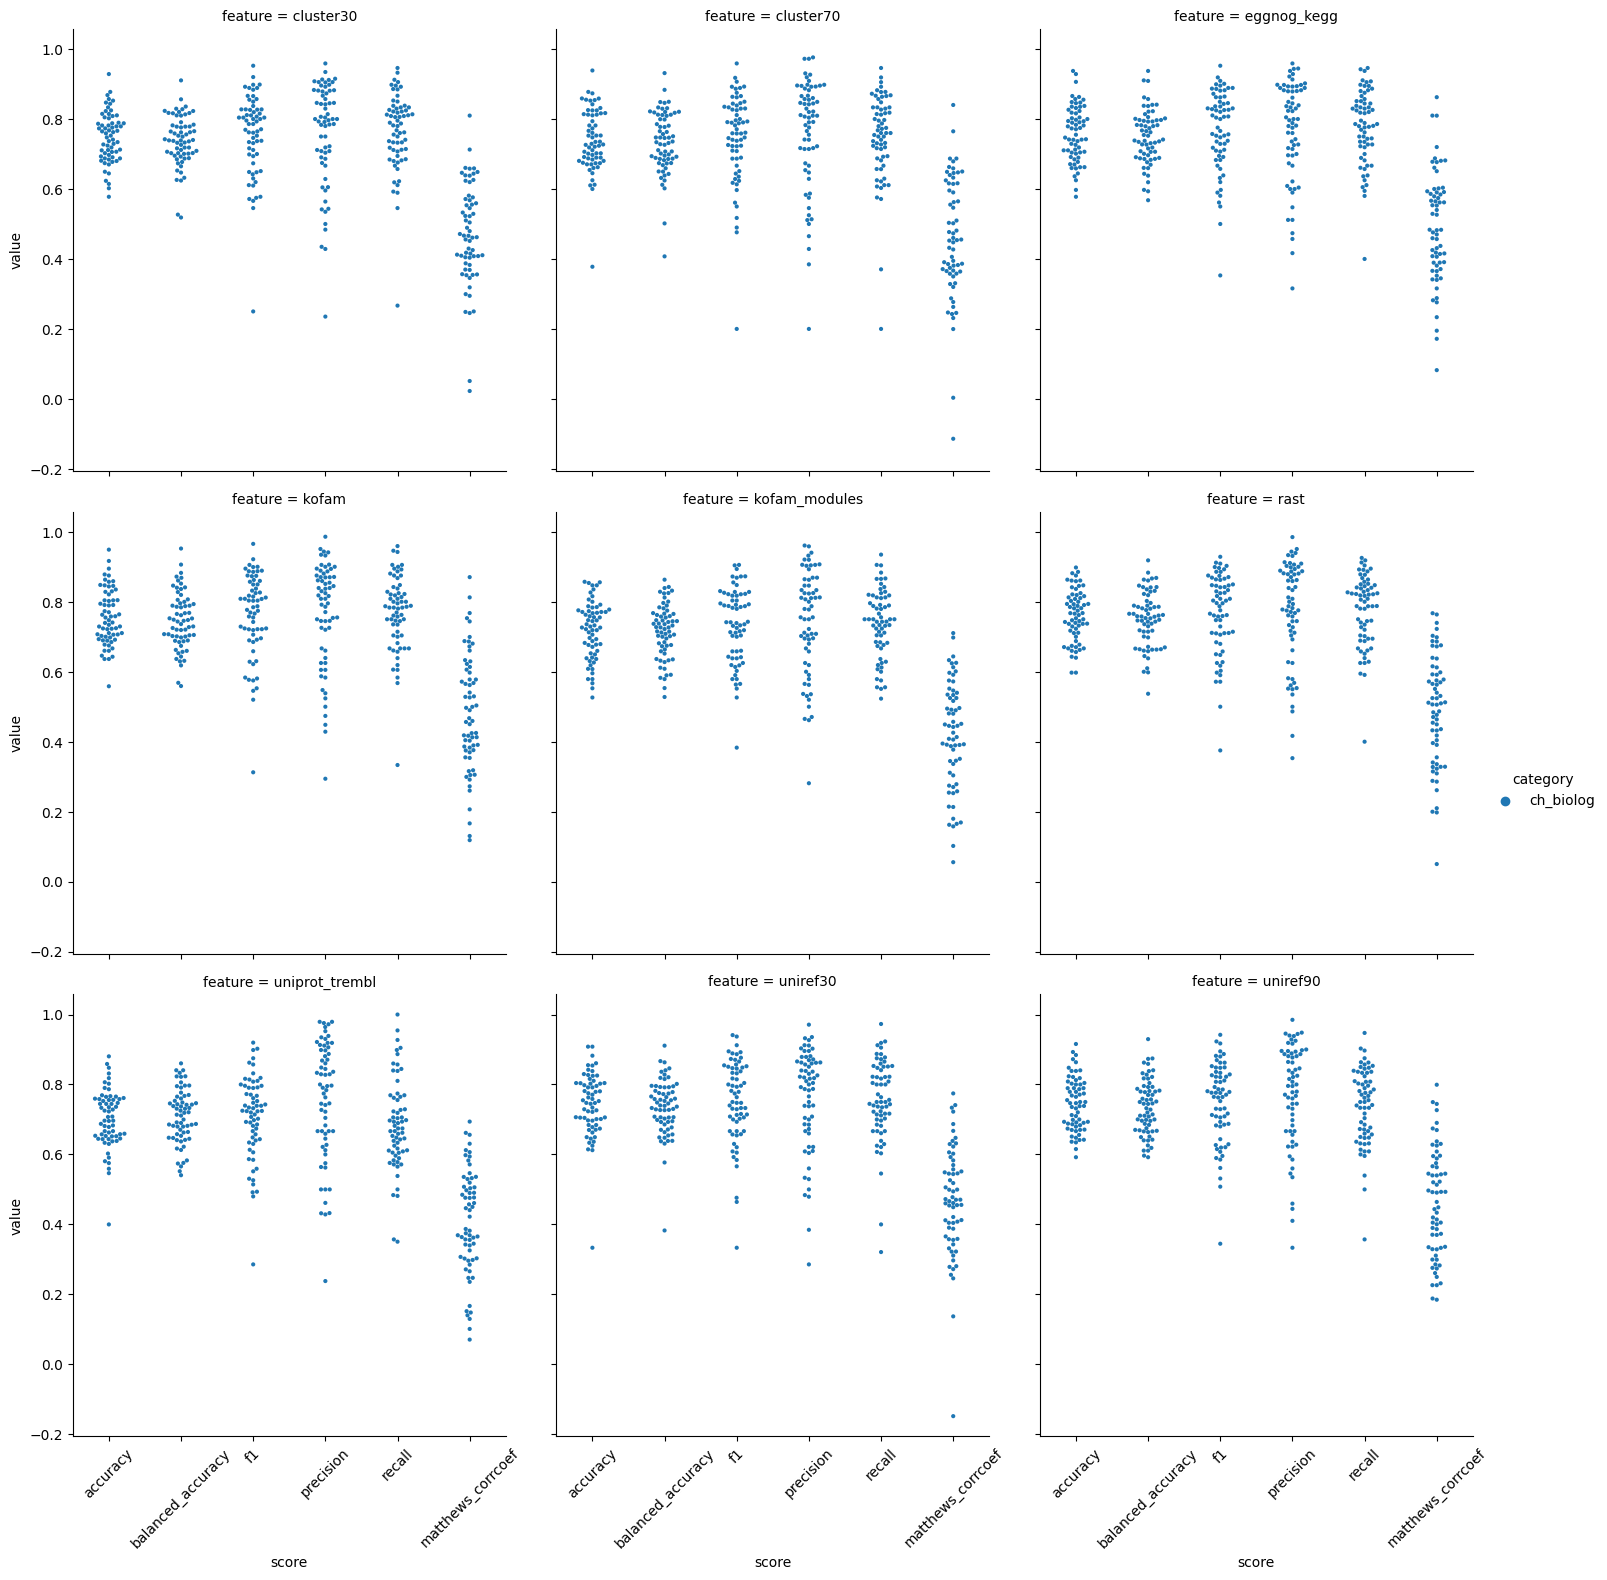

In [10]:
g = sns.catplot(data=all_scores_melt, x="score", y="value", hue="category", col="feature", col_wrap=3, size=3, kind="swarm")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, which="both");
# g.figure.tight_layout();
# g.add_legend();

/Users/g8k/mambaforge/envs/trait-prediction/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/g8k/mambaforge/envs/trait-prediction/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/g8k/mambaforge/envs/trait-prediction/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 7.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/g8k/mambaforge/envs/trait-prediction/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 14.1% of the points cannot be placed; yo

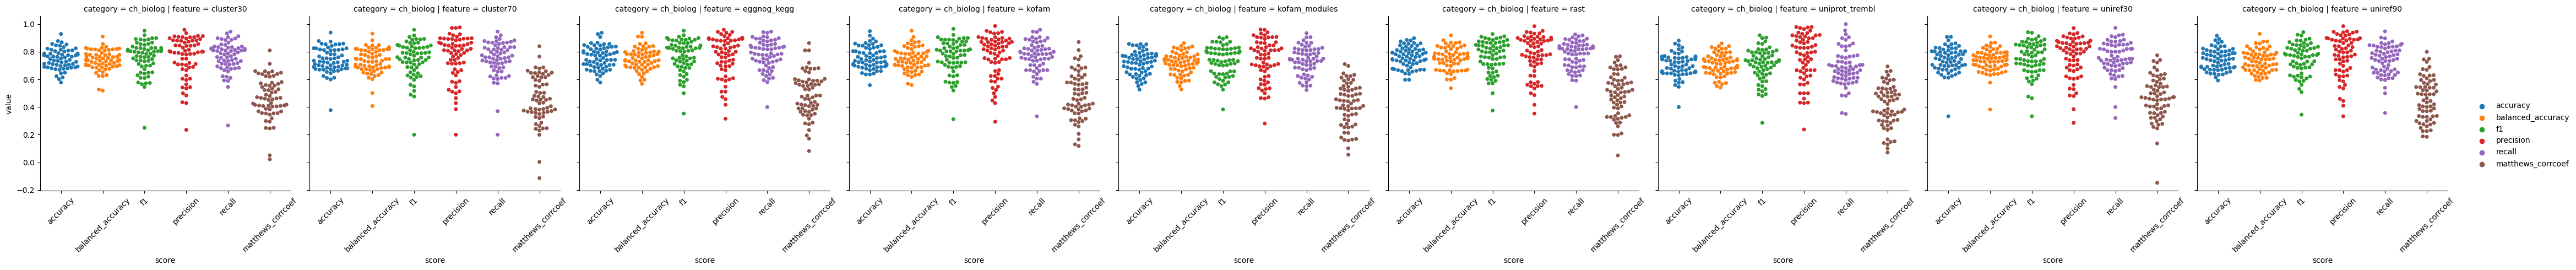

In [11]:
g = sns.catplot(data=all_scores_melt, x="score", y="value", hue="score", col="feature", row="category", kind="swarm")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, which="both");
g.figure.tight_layout();
g.add_legend();

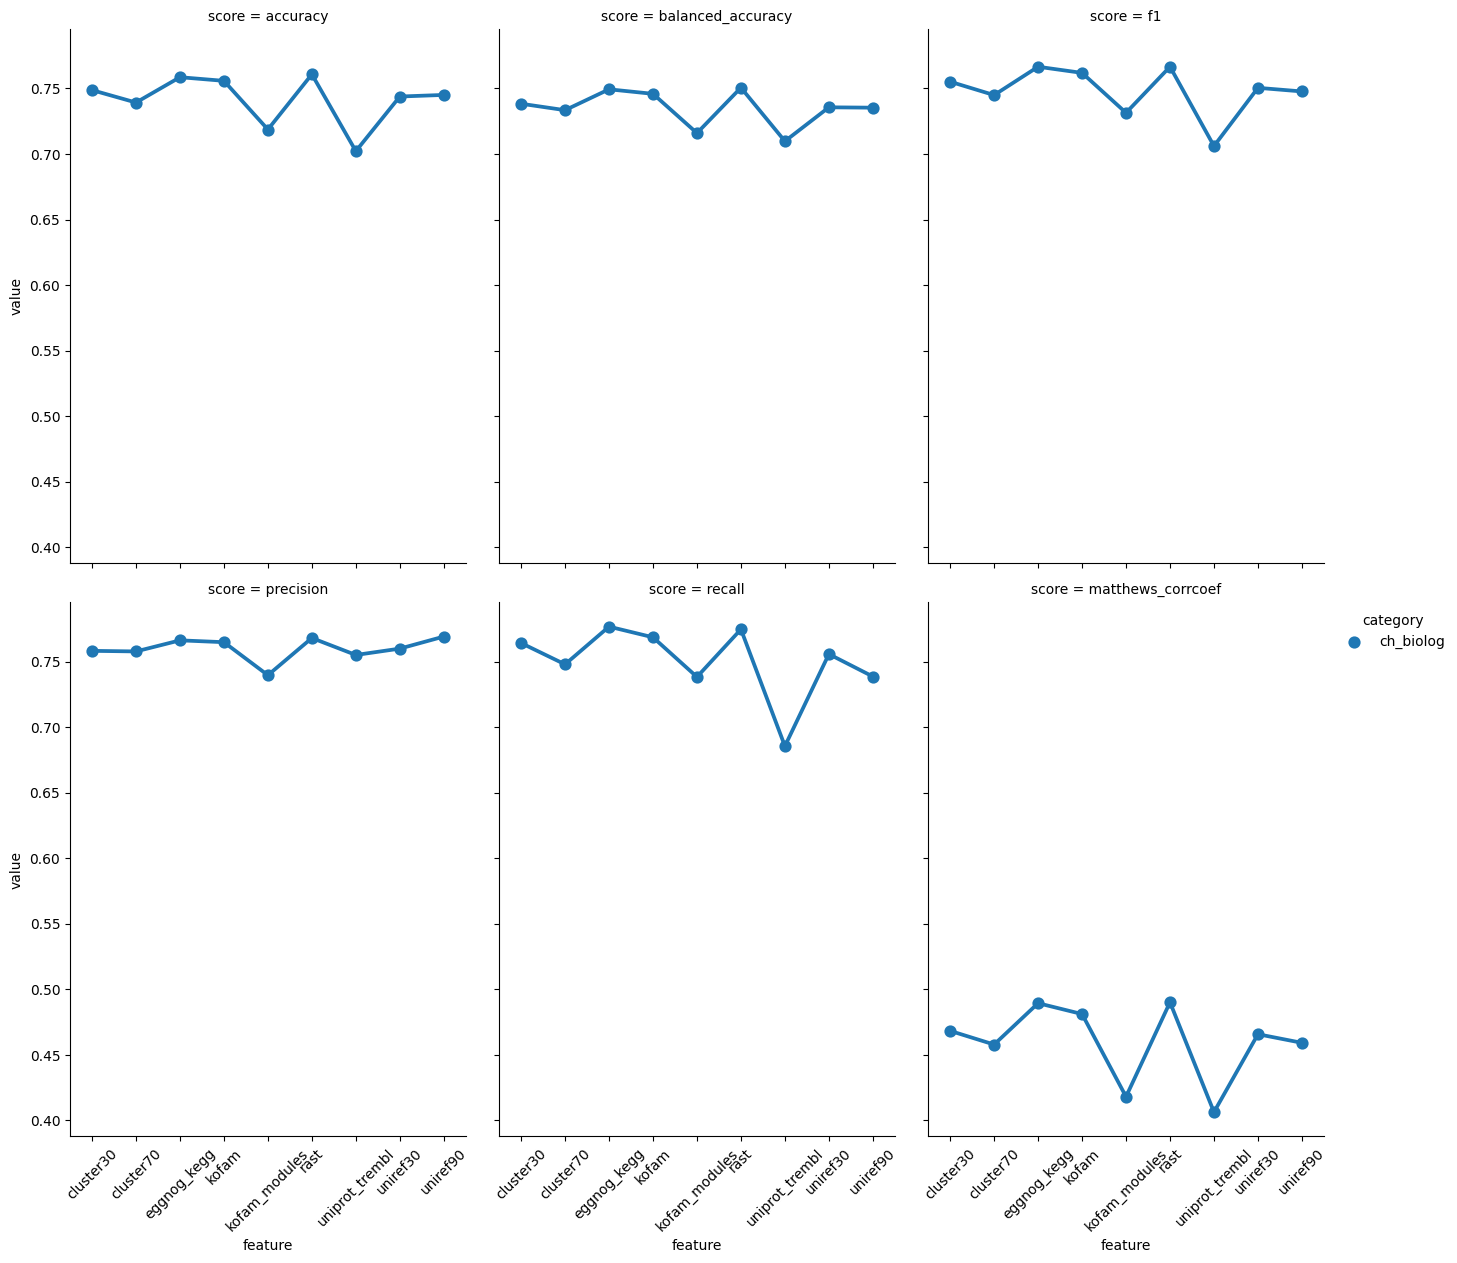

In [12]:
g = sns.catplot(all_scores_mean_melt, x="feature", y="value", hue="category", col="score", col_wrap=3, errorbar="se", kind="point", height=6, aspect=.75)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, which="both");

In [13]:
all_scores

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef,feature
Carbon-N-Acetyl-Neuraminic-Acid-ch_biolog,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,0.649351,0.647019,0.619718,0.628571,0.611111,0.294637,cluster30
Carbon-Sucrose-ch_biolog,Carbon-Sucrose,ch_biolog,0.718750,0.702429,0.769231,0.750000,0.789474,0.410720,cluster30
Carbon-Dextrin-ch_biolog,Carbon-Dextrin,ch_biolog,0.644444,0.652778,0.609756,0.543478,0.694444,0.299456,cluster30
Carbon-Gelatin-ch_biolog,Carbon-Gelatin,ch_biolog,0.705882,0.702778,0.731183,0.708333,0.755556,0.408287,cluster30
Carbon-Salicin-ch_biolog,Carbon-Salicin,ch_biolog,0.702381,0.702496,0.698795,0.690476,0.707317,0.404877,cluster30
...,...,...,...,...,...,...,...,...,...
Carbon-D-Mannose-ch_biolog,Carbon-D-Mannose,ch_biolog,0.812500,0.782535,0.869565,0.895522,0.845070,0.540089,uniref90
Carbon-D-Mannitol-ch_biolog,Carbon-D-Mannitol,ch_biolog,0.838710,0.816810,0.881890,0.888889,0.875000,0.627896,uniref90
Carbon-L-Alanine-ch_biolog,Carbon-L-Alanine,ch_biolog,0.691489,0.710714,0.764228,0.886792,0.671429,0.370552,uniref90
Carbon-D-Cellobiose-ch_biolog,Carbon-D-Cellobiose,ch_biolog,0.673913,0.667641,0.716981,0.730769,0.703704,0.333018,uniref90


In [14]:
bac_scores = all_scores_melt[all_scores_melt.score == "balanced_accuracy"].pivot(index="name", columns="feature", values="value")
bac_scores

feature,cluster30,cluster70,eggnog_kegg,kofam,kofam_modules,rast,uniprot_trembl,uniref30,uniref90
name,,,,,,,,,
Carbon-Acetic-Acid,0.518519,0.407407,0.567901,0.629630,0.676389,0.537037,0.612825,0.382716,0.675000
Carbon-Acetoacetic-Acid,0.624157,0.612011,0.597503,0.559042,0.578947,0.598178,0.575826,0.637652,0.592105
Carbon-Citric-Acid,0.632102,0.631629,0.715909,0.662405,0.589663,0.638258,0.699777,0.647727,0.719841
Carbon-D-Arabitol,0.778571,0.780952,0.779365,0.768254,0.754762,0.780159,0.737209,0.756349,0.781301
Carbon-D-Aspartic-Acid,0.526776,0.501639,0.593443,0.568306,0.611475,0.609836,0.540640,0.577049,0.596604
...,...,...,...,...,...,...,...,...,...
Carbon-b-Methyl-D-Glucoside,0.776050,0.820786,0.773868,0.788871,0.839186,0.788871,0.711124,0.801691,0.699085
Carbon-g-Amino-Butyric-Acid,0.761947,0.685783,0.676523,0.720430,0.681302,0.752688,0.741914,0.685783,0.759259
Carbon-g-Hydroxy-Butyric-Acid,0.813283,0.849311,0.822368,0.840226,0.831767,0.831140,0.713636,0.866855,0.862573


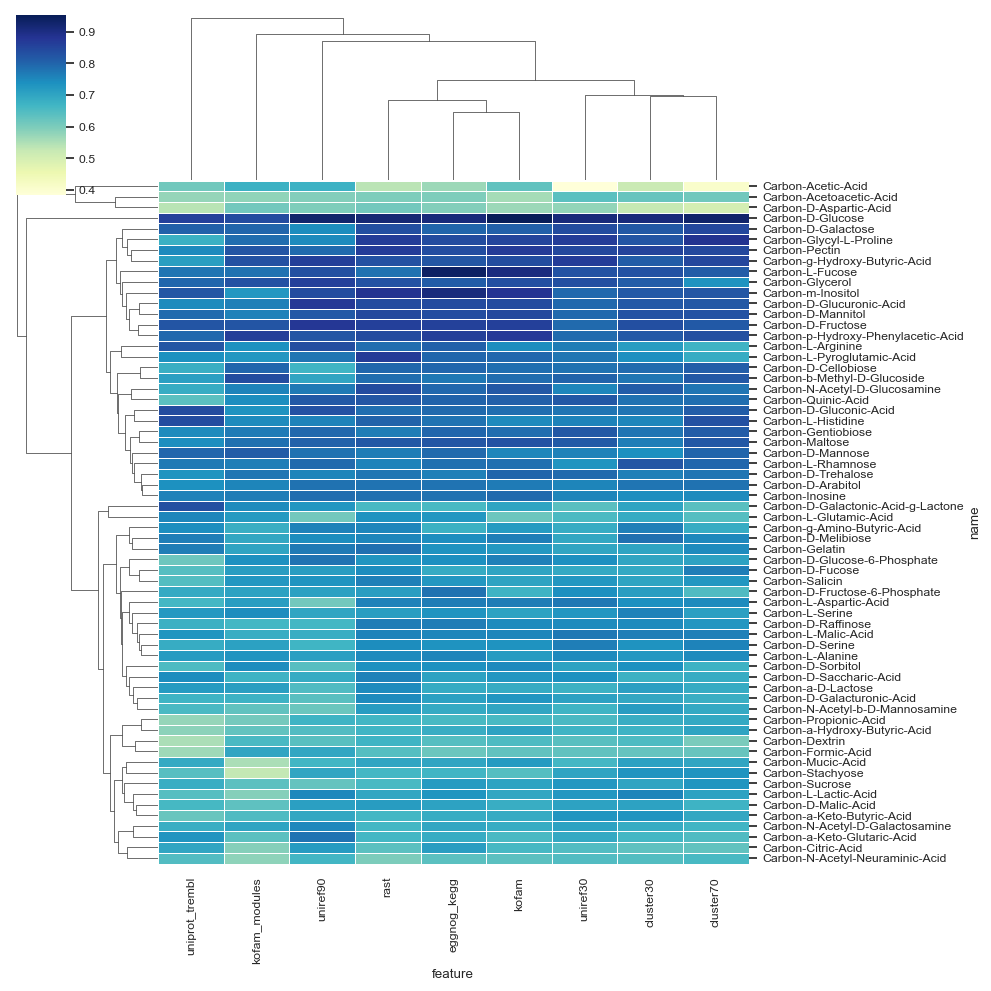

In [30]:
sns.set(font_scale=0.8)
sns.clustermap(bac_scores,  linewidths=.5, cmap="YlGnBu", yticklabels=1)

In [32]:
acc_scores = all_scores_melt[all_scores_melt.score == "accuracy"].pivot(index="name", columns="feature", values="value")
acc_scores

feature,cluster30,cluster70,eggnog_kegg,kofam,kofam_modules,rast,uniprot_trembl,uniref30,uniref90
name,,,,,,,,,
Carbon-Acetic-Acid,0.577778,0.377778,0.577778,0.688889,0.595506,0.700000,0.400000,0.333333,0.818182
Carbon-Acetoacetic-Acid,0.623377,0.610390,0.597403,0.558442,0.578947,0.597403,0.575342,0.636364,0.592105
Carbon-Citric-Acid,0.602041,0.612245,0.704082,0.642857,0.567010,0.642857,0.652174,0.612245,0.655914
Carbon-D-Arabitol,0.781609,0.781609,0.781609,0.770115,0.758621,0.781609,0.734940,0.758621,0.779070
Carbon-D-Aspartic-Acid,0.684211,0.684211,0.710526,0.710526,0.618421,0.736842,0.652778,0.684211,0.746667
...,...,...,...,...,...,...,...,...,...
Carbon-b-Methyl-D-Glucoside,0.779070,0.825581,0.779070,0.790698,0.847059,0.790698,0.707317,0.802326,0.690476
Carbon-g-Amino-Butyric-Acid,0.741176,0.670588,0.658824,0.705882,0.682353,0.729412,0.728395,0.670588,0.738095
Carbon-g-Hydroxy-Butyric-Acid,0.847059,0.858824,0.847059,0.858824,0.835294,0.858824,0.790123,0.882353,0.892857


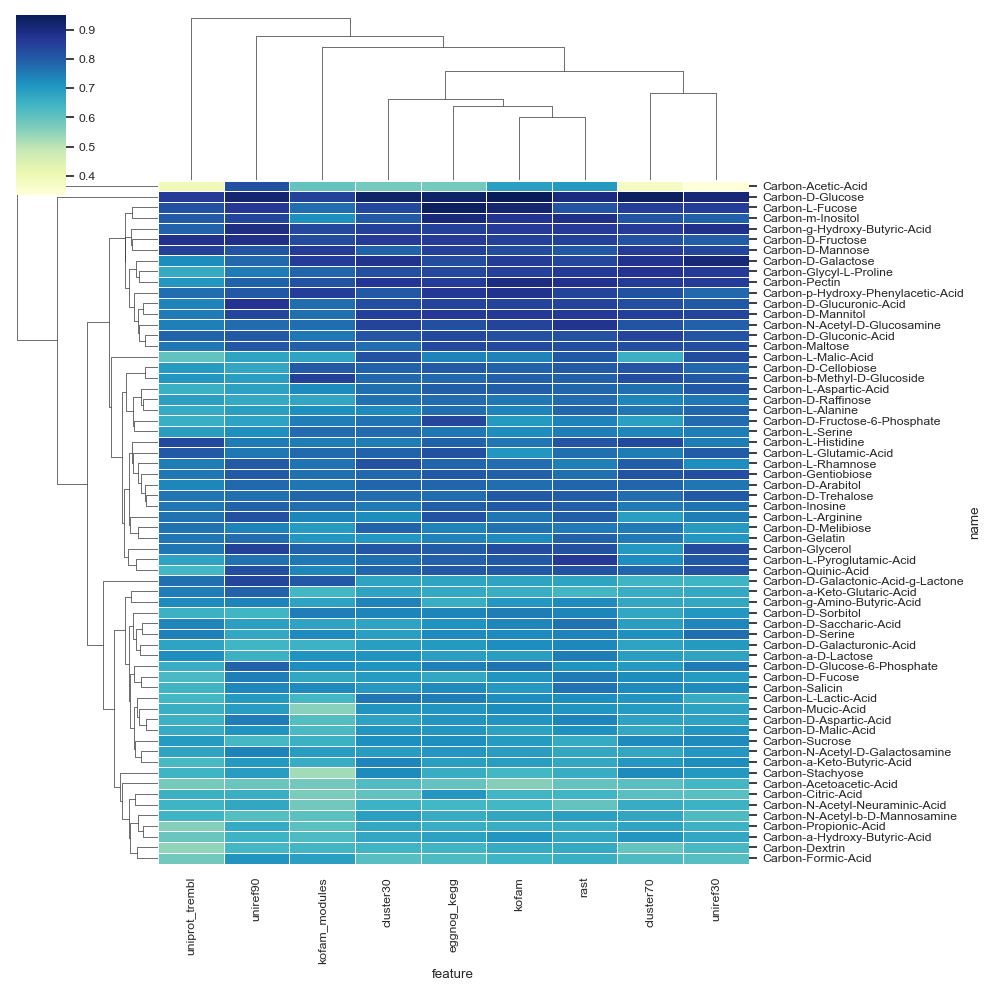

In [33]:
sns.set(font_scale=0.8)
sns.clustermap(acc_scores,  linewidths=.5, cmap="YlGnBu", yticklabels=1)

In [16]:
mcc_scores = all_scores_melt[all_scores_melt.score == "matthews_corrcoef"].pivot(index="name", columns="feature", values="value")
mcc_scores

feature,cluster30,cluster70,eggnog_kegg,kofam,kofam_modules,rast,uniprot_trembl,uniref30,uniref90
name,,,,,,,,,
Carbon-Acetic-Acid,0.022582,-0.113961,0.082216,0.166431,0.213381,0.050252,0.140187,-0.148090,0.260875
Carbon-Acetoacetic-Acid,0.250006,0.231150,0.195007,0.118565,0.157895,0.197695,0.151994,0.280657,0.184787
Carbon-Citric-Acid,0.248624,0.246957,0.406353,0.304636,0.169071,0.261307,0.369092,0.278557,0.419928
Carbon-D-Arabitol,0.567756,0.562500,0.564738,0.540527,0.524737,0.563005,0.476921,0.518211,0.563366
Carbon-D-Aspartic-Acid,0.051149,0.003279,0.171780,0.130482,0.179729,0.209814,0.070774,0.137157,0.188206
...,...,...,...,...,...,...,...,...,...
Carbon-b-Methyl-D-Glucoside,0.553461,0.647426,0.552734,0.577741,0.697696,0.577741,0.422249,0.602234,0.400467
Carbon-g-Amino-Butyric-Acid,0.504386,0.357729,0.340088,0.424443,0.351051,0.486827,0.461086,0.357729,0.496904
Carbon-g-Hydroxy-Butyric-Acid,0.646306,0.687094,0.650883,0.680451,0.643675,0.675532,0.489845,0.733709,0.749659


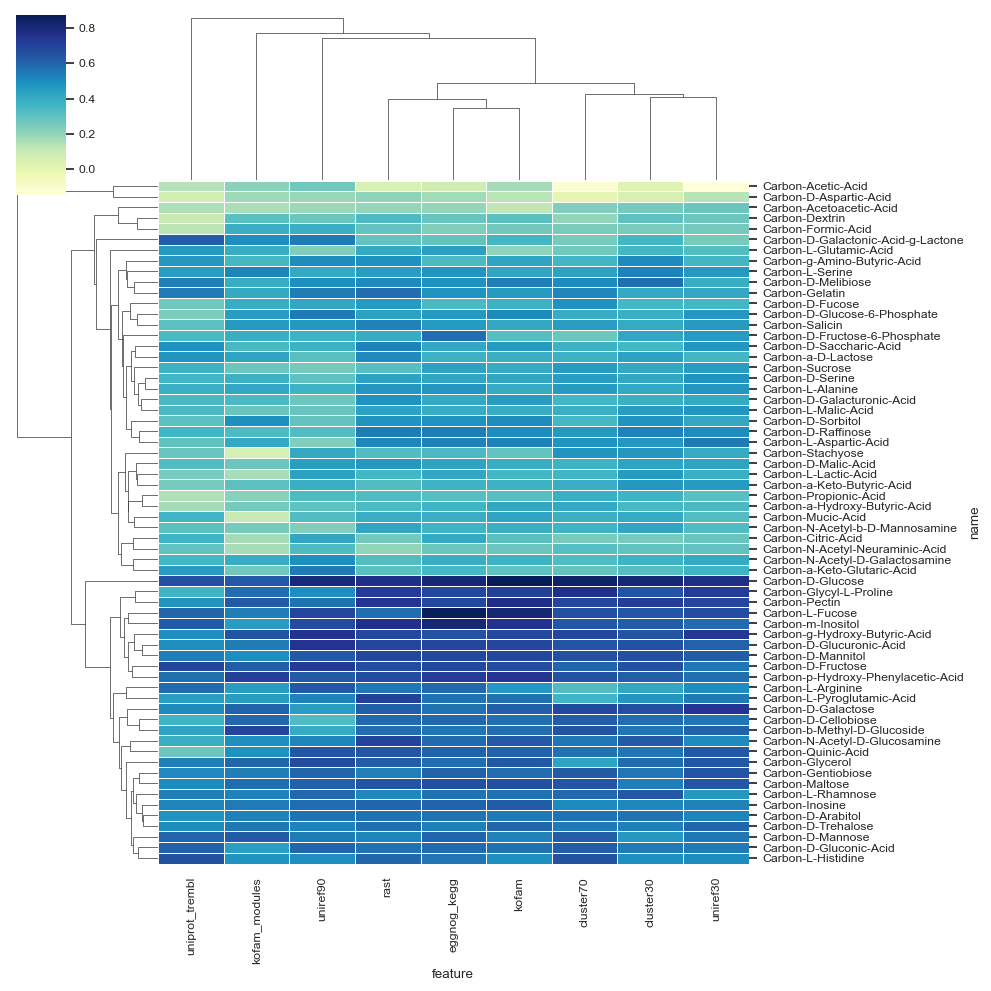

In [31]:
sns.set(font_scale=0.8)
sns.clustermap(mcc_scores,  linewidths=.5, cmap="YlGnBu", yticklabels=1)